https://huggingface.co/datasets/benstaf/nasdaq_2013_2023/tree/main

1. sentiment_nasdaq_news.csv was the input file
2. sentiment analysis was done with a different prompt and a comparison between the outputs from the original prompt and the modified prompt was done. A histogram was generated

In [38]:
from google.colab import drive
drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/finrl_data/sentiment_nasdaq_news.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import pandas as pd

chunk_size = 100_000  # or even 50_000 if needed

for chunk in pd.read_csv(csv_path, chunksize=chunk_size):
    print(chunk.head())  # or do processing here


   Unnamed: 0.1  Unnamed: 0                     Date  \
0             0     12034.0  2023-12-16 18:00:00 UTC   
1             1     12068.0  2023-12-15 00:00:00 UTC   
2             2     12072.0  2023-12-14 00:00:00 UTC   
3             3     12092.0  2023-12-13 00:00:00 UTC   
4             4     12138.0  2023-12-12 00:00:00 UTC   

                                       Article_title Stock_symbol  \
0  Is FlexShares STOXX US ESG Select Index Fund (...         AAPL   
1                   Guru Fundamental Report for AAPL         AAPL   
2  2 Hot Warren Buffett Stocks That Raised Their ...         AAPL   
3  Technology Sector Update for 12/14/2023: ADBE,...         AAPL   
4  Up 149% YTD, How High Can Roku (NASDAQ:ROKU) S...         AAPL   

                                                 Url Publisher  Author  \
0  https://www.nasdaq.com/articles/is-flexshares-...       NaN     NaN   
1  https://www.nasdaq.com/articles/guru-fundament...       NaN     NaN   
2  https://www.nasdaq.com/

In [40]:
chunk.tail()

,Unnamed: 0.1,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary,Sentiment_llama3.1-8b
14052,14052,626260.0,2021-08-13 00:00:00 UTC,3 No-Brainer Stocks to Consider if You're Worr...,COST,https://www.nasdaq.com/articles/3-no-brainer-s...,NaN,NaN,As the world slowly opens back up and the econ...,It's Costco Wholesale's (NASDAQ: COST) valuabl...,It's Costco Wholesale's (NASDAQ: COST) valuabl...,"Chipotle, Costco, and Netflix are all companie...","Earlier this year, Costco announced that start...",NaN
14053,14053,626262.0,2021-08-10 00:00:00 UTC,2 Retail Stocks You Can Buy and Hold for the N...,COST,https://www.nasdaq.com/articles/2-retail-stock...,NaN,NaN,"While it may seem like time flies by, a decade...",The approach continues to retain and attract m...,Costco Costco (NASDAQ: COST) is known for sell...,Costco ended last year with 58.1 million payin...,The Motley Fool owns shares of and recommends ...,NaN
14054,14054,626263.0,2021-08-09 00:00:00 UTC,Best Consumer Discretionary Stocks To Buy Now?...,COST,https://www.nasdaq.com/articles/best-consumer-...,NaN,NaN,5 Hot Consumer Discretionary Stocks For Your L...,5 Top Consumer Discretionary Stocks To Watch T...,5 Top Consumer Discretionary Stocks To Watch T...,5 Top Consumer Discretionary Stocks To Watch T...,5 Top Consumer Discretionary Stocks To Watch T...,NaN
14055,14055,626264.0,2021-08-08 00:00:00 UTC,7 REITs I Own and Never Plan to Sell,COST,https://www.nasdaq.com/articles/7-reits-i-own-...,NaN,NaN,"I'm known around The Motley Fool as ""The REIT ...","They own a lot of Dollar Store properties, who...","They own a lot of Dollar Store properties, who...","They own a lot of Dollar Store properties, who...","They own a lot of Dollar Store properties, who...",NaN
14056,14056,626265.0,2021-08-06 00:00:00 UTC,"Notable Friday Option Activity: COST, ETSY, JPM",COST,https://www.nasdaq.com/articles/notable-friday...,NaN,NaN,Looking at options trading activity among comp...,Especially high volume was seen for the $440 s...,Below is a chart showing COST's trailing twelv...,Looking at options trading activity among comp...,Looking at options trading activity among comp...,NaN


In [41]:
chunks = []
for chunk in pd.read_csv(csv_path, chunksize=chunk_size):
    chunks.append(chunk)

# Concatenate all chunks into a single DataFrame
df_full = pd.concat(chunks, ignore_index=True)

In [42]:
df_full.tail()

,Unnamed: 0.1,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary,Sentiment_llama3.1-8b
14052,14052,626260.0,2021-08-13 00:00:00 UTC,3 No-Brainer Stocks to Consider if You're Worr...,COST,https://www.nasdaq.com/articles/3-no-brainer-s...,NaN,NaN,As the world slowly opens back up and the econ...,It's Costco Wholesale's (NASDAQ: COST) valuabl...,It's Costco Wholesale's (NASDAQ: COST) valuabl...,"Chipotle, Costco, and Netflix are all companie...","Earlier this year, Costco announced that start...",NaN
14053,14053,626262.0,2021-08-10 00:00:00 UTC,2 Retail Stocks You Can Buy and Hold for the N...,COST,https://www.nasdaq.com/articles/2-retail-stock...,NaN,NaN,"While it may seem like time flies by, a decade...",The approach continues to retain and attract m...,Costco Costco (NASDAQ: COST) is known for sell...,Costco ended last year with 58.1 million payin...,The Motley Fool owns shares of and recommends ...,NaN
14054,14054,626263.0,2021-08-09 00:00:00 UTC,Best Consumer Discretionary Stocks To Buy Now?...,COST,https://www.nasdaq.com/articles/best-consumer-...,NaN,NaN,5 Hot Consumer Discretionary Stocks For Your L...,5 Top Consumer Discretionary Stocks To Watch T...,5 Top Consumer Discretionary Stocks To Watch T...,5 Top Consumer Discretionary Stocks To Watch T...,5 Top Consumer Discretionary Stocks To Watch T...,NaN
14055,14055,626264.0,2021-08-08 00:00:00 UTC,7 REITs I Own and Never Plan to Sell,COST,https://www.nasdaq.com/articles/7-reits-i-own-...,NaN,NaN,"I'm known around The Motley Fool as ""The REIT ...","They own a lot of Dollar Store properties, who...","They own a lot of Dollar Store properties, who...","They own a lot of Dollar Store properties, who...","They own a lot of Dollar Store properties, who...",NaN
14056,14056,626265.0,2021-08-06 00:00:00 UTC,"Notable Friday Option Activity: COST, ETSY, JPM",COST,https://www.nasdaq.com/articles/notable-friday...,NaN,NaN,Looking at options trading activity among comp...,Especially high volume was seen for the $440 s...,Below is a chart showing COST's trailing twelv...,Looking at options trading activity among comp...,Looking at options trading activity among comp...,NaN


In [43]:
df_full.shape

(14057, 14)

In [44]:
df_full.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol',
       'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary',
       'Textrank_summary', 'Lexrank_summary', 'Sentiment_llama3.1-8b'],
      dtype='object')

In [45]:
df_full = df_full[['Date', 'Stock_symbol', 'Lsa_summary']]

In [46]:
df_full.columns

Index(['Date', 'Stock_symbol', 'Lsa_summary'], dtype='object')

In [47]:
df_full.head()

,Date,Stock_symbol,Lsa_summary
0,2023-12-16 18:00:00 UTC,AAPL,"Taking into account individual holdings, Amazo..."
1,2023-12-15 00:00:00 UTC,AAPL,APPLE INC (AAPL) is a large-cap growth stock i...
2,2023-12-14 00:00:00 UTC,AAPL,Let's dig into the payout enhancements from th...
3,2023-12-13 00:00:00 UTC,AAPL,Apple (AAPL) and Alphabet's (GOOG) Google were...
4,2023-12-12 00:00:00 UTC,AAPL,Roku is also valued cheaper than its bigger co...


In [48]:
df_full.tail()

,Date,Stock_symbol,Lsa_summary
14052,2021-08-13 00:00:00 UTC,COST,It's Costco Wholesale's (NASDAQ: COST) valuabl...
14053,2021-08-10 00:00:00 UTC,COST,The approach continues to retain and attract m...
14054,2021-08-09 00:00:00 UTC,COST,5 Top Consumer Discretionary Stocks To Watch T...
14055,2021-08-08 00:00:00 UTC,COST,"They own a lot of Dollar Store properties, who..."
14056,2021-08-06 00:00:00 UTC,COST,Especially high volume was seen for the $440 s...


In [49]:
tickers_full = list(df_full['Stock_symbol'].unique())
print(tickers_full)

['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALGN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'AVGO', 'AZN', 'BIIB', 'BKNG', 'BKR', 'CDNS', 'CHTR', 'CMCSA', 'COST']


In [50]:
filtered_chunks = []
for chunk in pd.read_csv(csv_path, chunksize=chunk_size):
    filtered = chunk[chunk['Stock_symbol'] == 'AAPL']
    filtered_chunks.append(filtered)

df_aapl = pd.concat(filtered_chunks, ignore_index=True)

In [51]:
df_aapl.tail()

,Unnamed: 0.1,Unnamed: 0,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary,Sentiment_llama3.1-8b
553,553,20833.0,2022-06-07 00:00:00 UTC,"US STOCKS-Wall St gains with tech, energy; Tar...",AAPL,https://www.nasdaq.com/articles/us-stocks-wall...,NaN,NaN,"By Caroline Valetkevitch\nNEW YORK, June 7 (Re...",Apple Inc AAPL.O shares were up 1.8%. The gain...,Apple Inc AAPL.O shares were up 1.8%. By Carol...,Apple Inc AAPL.O shares were up 1.8%. By Carol...,Apple Inc AAPL.O shares were up 1.8%. By Carol...,NaN
554,554,20869.0,2022-06-06 00:00:00 UTC,"Don’t Fear Recession, Prepare Instead",AAPL,https://www.nasdaq.com/articles/dont-fear-rece...,NaN,NaN,"InvestorPlace - Stock Market News, Stock Advic...","Furthermore, many of our Breakthrough Stocks a...","Furthermore, many of our Breakthrough Stocks a...","Furthermore, many of our Breakthrough Stocks a...","Furthermore, many of our Breakthrough Stocks a...",NaN
555,555,20873.0,2022-06-05 00:00:00 UTC,"If I Could Buy Only 1 Warren Buffett Stock, Th...",AAPL,https://www.nasdaq.com/articles/if-i-could-buy...,NaN,NaN,Don't underestimate the power of Berkshire Hat...,Apple (NASDAQ: AAPL) ranks as the biggest hold...,Apple (NASDAQ: AAPL) ranks as the biggest hold...,Apple (NASDAQ: AAPL) ranks as the biggest hold...,Apple (NASDAQ: AAPL) ranks as the biggest hold...,4.0
556,556,20876.0,2022-06-04 00:00:00 UTC,How Advertising's Massive Shift Affects Facebo...,AAPL,https://www.nasdaq.com/articles/how-advertisin...,NaN,NaN,The digital advertising landscape changed dram...,The app tracking transparency changes that App...,The app tracking transparency changes that App...,The app tracking transparency changes that App...,The app tracking transparency changes that App...,3.0
557,557,20889.0,2022-06-03 00:00:00 UTC,Consider Alphabet Stock Even in a Recession,AAPL,https://www.nasdaq.com/articles/consider-alpha...,NaN,NaN,"InvestorPlace - Stock Market News, Stock Advic...","This is why the Federal Reserve (Fed), who con...","InvestorPlace - Stock Market News, Stock Advic...","Ticker Company Price GOOG Alphabet Inc. $2,202...","Ticker Company Price GOOG Alphabet Inc. $2,202...",3.0


In [52]:
df_aapl=df_aapl[['Date', 'Stock_symbol', 'Lsa_summary']]

In [53]:
df_full.isna().sum()

,0
Date,0
Stock_symbol,0
Lsa_summary,486


In [54]:
df_aapl.isna().sum()

,0
Date,0
Stock_symbol,0
Lsa_summary,0


In [55]:
df_full.shape

(14057, 3)

In [56]:
df_full.to_csv('/content/sentiment_nasdaq_news_filtered_columns_allstocks.csv', index=False)

In [57]:
df_aapl.shape

(558, 3)

In [58]:
df_aapl.columns

Index(['Date', 'Stock_symbol', 'Lsa_summary'], dtype='object')

In [59]:
df_aapl

,Date,Stock_symbol,Lsa_summary
0,2023-12-16 18:00:00 UTC,AAPL,"Taking into account individual holdings, Amazo..."
1,2023-12-15 00:00:00 UTC,AAPL,APPLE INC (AAPL) is a large-cap growth stock i...
2,2023-12-14 00:00:00 UTC,AAPL,Let's dig into the payout enhancements from th...
3,2023-12-13 00:00:00 UTC,AAPL,Apple (AAPL) and Alphabet's (GOOG) Google were...
4,2023-12-12 00:00:00 UTC,AAPL,Roku is also valued cheaper than its bigger co...
...,...,...,...
553,2022-06-07 00:00:00 UTC,AAPL,Apple Inc AAPL.O shares were up 1.8%. The gain...
554,2022-06-06 00:00:00 UTC,AAPL,"Furthermore, many of our Breakthrough Stocks a..."
555,2022-06-05 00:00:00 UTC,AAPL,Apple (NASDAQ: AAPL) ranks as the biggest hold...
556,2022-06-04 00:00:00 UTC,AAPL,The app tracking transparency changes that App...


In [60]:
df_aapl.to_csv('/content/aapl_filtered.csv', index=False)

In [61]:
tickers = list(df_full['Stock_symbol'].unique())
print(tickers)

['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALGN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'AVGO', 'AZN', 'BIIB', 'BKNG', 'BKR', 'CDNS', 'CHTR', 'CMCSA', 'COST']


In [62]:
df_temp = pd.read_csv('/content/aapl_filtered.csv')
df_temp.shape

(558, 3)

# The following code connects to DeepSeek-V3 and gets the sentiments for each of the rows in Lsa_summary. This .ipynb deals with Chain of Thought Learning Prompts

In [63]:
import os
import time
import numpy as np
import pandas as pd
from openai import OpenAI

In [64]:
# Set your OpenAI API key and base URL
openai = OpenAI(
    api_key= "0vhRLHAgQlk7dYSVUWoBOrBQwmDsYoOU",  #Replace with your actual DeepInfra api key
    base_url="https://api.deepinfra.com/v1/openai",
)

In [65]:
stream = False  # Set to True if you want to stream the response
model_used = 'sentiment_deepseek'  # Define the model_used variable

In [66]:
#Chain of Thought
#option for few shot  leading to sentiment_chainofthought.csv

def get_sentiment_chainofthought(symbol, *texts):
    texts = [text for text in texts if text != 0]
    num_text = len(texts)
    text_content = " ".join([f"### News to Stock Symbol -- {symbol}: {text}" for text in texts])

    conversation = [
{
            "role": "system",
            "content": (
                "You are a financial sentiment analysis expert. Your task is to evaluate sentiment of news headlines "
                "about specific stock symbols. Use a scoring scale from 1 to 5:\n"
                "1 = Strong Negative, 2 = Mild Negative, 3 = Neutral, 4 = Mild Positive, 5 = Strong Positive.\n\n"
                "For each headline, analyze its sentiment *in the context of its effect on the stock*, and respond with "
                "a comma-separated list of scores in order.\n\n"
                f"{num_text} news items will be provided per query."
            )
        },
        {
            "role": "user",
            "content": (
                "### News to Stock Symbol -- AAPL: Apple (AAPL) revenue drops 12% in Q2\n"
                "### News to Stock Symbol -- AAPL: Apple launches new iPhone SE at budget pricing\n"
                "### News to Stock Symbol -- MSFT: Microsoft (MSFT) completes acquisition of OpenAI stake"
            )
        },
        {"role": "assistant", "content": "2, 4, 4"},
        {
            "role": "user",
            "content": (
                "### News to Stock Symbol -- TSLA: Tesla (TSLA) vehicles recalled for braking issue\n"
                "### News to Stock Symbol -- TSLA: Tesla announces 2-for-1 stock split"
            )
        },
        {"role": "assistant", "content": "1, 5"},
        {
            "role": "user",
            "content": text_content
        }

    ]

    return conversation


In [67]:
def build_chainofthought_prompt(symbol, texts):
    """
    Builds a chain of thought reasoning prompt for a list of financial headlines.
    """
    prompt = (
        "You are a financial analyst. For each headline, consider what the opposite situation would be "
        "(a counterfactual), and then reason whether the actual news is positive, negative, or neutral.\n"
        "Assign a sentiment score from 1 to 5 (1 = very negative, 5 = very positive).\n"
        "Respond only with: Score: X for each headline.\n\n"
    )

    # Add chainofthought examples
    chainofthought_examples_cot = [
        {
            "headline": "Apple stock rises as iPhone sales beat expectations",
            "reasoning": "The news highlights better-than-expected sales which positively impacts investor sentiment.",
            "sentiment": "positive"
        },
        {
            "headline": "Tesla shares tumble amid supply chain concerns",
            "reasoning": "Supply chain issues negatively affect operations and investor outlook.",
            "sentiment": "negative"
        },
        {
            "headline": "Google remains steady despite ad revenue slowdown",
            "reasoning": "While ad revenue slowed, overall stability indicates neutral sentiment.",
            "sentiment": "neutral"
        }
    ]


    for example in chainofthought_examples_cot:
        prompt += f"News: {example['headline']}\n{example['sentiment']}\n\n"

    # Add target headlines
    for i, text in enumerate(texts, 1):
        prompt += f"{i}. News to Stock Symbol -- {symbol}: {text.strip()}\n"

    prompt += "\nReturn sentiment scores only as:\nScore: 3\nScore: 2\nScore: 5 ..."

    return prompt

"""    # Add chainofthought examples with reasoning

    for ex in chainofthought_examples_cot:
        prompt += (
            f"News: {ex['headline']}\n"
            f"Reasoning: {ex['reasoning']}\n"
            f"Sentiment: {ex['sentiment']}\n\n"
        )

    # Append the day's actual news for the given stock symbol
    for text in texts:
        prompt += f"News: {text}\nReasoning:"

    return prompt"""


'    # Add chainofthought examples with reasoning\n    \n    for ex in chainofthought_examples_cot:\n        prompt += (\n            f"News: {ex[\'headline\']}\n"\n            f"Reasoning: {ex[\'reasoning\']}\n"\n            f"Sentiment: {ex[\'sentiment\']}\n\n"\n        )\n\n    # Append the day\'s actual news for the given stock symbol\n    for text in texts:\n        prompt += f"News: {text}\nReasoning:"\n    \n    return prompt'

In [68]:
def process_csv_chainofthought(input_path, output_path, batch_size=5, chunk_size=1000):
    import re
    reader = pd.read_csv(input_path, chunksize=chunk_size)
    all_results = []

    for chunk in reader:
        chunk = chunk.dropna(subset=['Lsa_summary'])
        chunk['sentiment'] = np.nan

        for i in range(0, len(chunk), batch_size):
            batch = chunk.iloc[i:i + batch_size]
            texts = batch['Lsa_summary'].tolist()
            symbol = batch['symbol'].iloc[0] if 'symbol' in batch.columns else "AAPL"

            try:
                prompt = build_chainofthought_prompt(symbol, texts)
                print(f"\n🧠 Calling LLM for {len(texts)} headlines...")

                chat_completion = openai.chat.completions.create(
                    model='deepseek-ai/DeepSeek-V3',
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0,
                    max_tokens=500,
                    stream=False,
                )

                # Validate response
                if not chat_completion or not chat_completion.choices:
                    raise ValueError("❌ No response or empty choices from LLM")

                content = chat_completion.choices[0].message.content

                if not content:
                    raise ValueError("❌ Response content is empty")

                print("🔍 LLM Output:\n", content)

                # Flexible sentiment score extraction
                scores = re.findall(r"(?:Score|Sentiment|Rating)[:=]?\s*([1-5])", content, re.IGNORECASE)
                print("🎯 Extracted Scores:", scores)

                sentiments = [int(score) for score in scores[:len(texts)]]

                if len(sentiments) < len(texts):
                    print(f"⚠️ Warning: Only extracted {len(sentiments)} scores for {len(texts)} texts.")

            except Exception as e:
                print(f"❌ Error: {e}")
                sentiments = [np.nan] * len(texts)

            chunk.loc[batch.index, 'sentiment'] = sentiments

        all_results.append(chunk)

    final_df = pd.concat(all_results)
    final_df.to_csv(output_path, index=False)
    print(f"\n✅ Saved results to {output_path}")

In [69]:
if __name__ == "__main__":
    input_file = '/content/aapl_filtered.csv'  # Replace with your input file path
    output_file = '/content/sentiment_chainofthought.csv'
    process_csv_chainofthought(input_file, output_file, batch_size=5, chunk_size=1000)


🧠 Calling LLM for 5 headlines...
🔍 LLM Output:
 Score: 3  
Score: 2  
Score: 5  
Score: 2  
Score: 3
🎯 Extracted Scores: ['3', '2', '5', '2', '3']

🧠 Calling LLM for 5 headlines...
🔍 LLM Output:
 Score: 3  
Score: 4  
Score: 5  
Score: 4  
Score: 3
🎯 Extracted Scores: ['3', '4', '5', '4', '3']

🧠 Calling LLM for 5 headlines...
🔍 LLM Output:
 Score: 4  
Score: 3  
Score: 2  
Score: 5  
Score: 4
🎯 Extracted Scores: ['4', '3', '2', '5', '4']

🧠 Calling LLM for 5 headlines...
🔍 LLM Output:
 Score: 3  
Score: 2  
Score: 5  
Score: 3  
Score: 2
🎯 Extracted Scores: ['3', '2', '5', '3', '2']

🧠 Calling LLM for 5 headlines...
🔍 LLM Output:
 Score: 5  
Score: 4  
Score: 2  
Score: 3  
Score: 3
🎯 Extracted Scores: ['5', '4', '2', '3', '3']

🧠 Calling LLM for 5 headlines...
🔍 LLM Output:
 Score: 4  
Score: 3  
Score: 5  
Score: 2  
Score: 3
🎯 Extracted Scores: ['4', '3', '5', '2', '3']

🧠 Calling LLM for 5 headlines...
🔍 LLM Output:
 Score: 3  
Score: 2  
Score: 5  
Score: 3  
Score: 4
🎯 Extracte

In [70]:
df_output=pd.read_csv('/content/sentiment_chainofthought.csv')
df_output

,Date,Stock_symbol,Lsa_summary,sentiment
0,2023-12-16 18:00:00 UTC,AAPL,"Taking into account individual holdings, Amazo...",3.0
1,2023-12-15 00:00:00 UTC,AAPL,APPLE INC (AAPL) is a large-cap growth stock i...,2.0
2,2023-12-14 00:00:00 UTC,AAPL,Let's dig into the payout enhancements from th...,5.0
3,2023-12-13 00:00:00 UTC,AAPL,Apple (AAPL) and Alphabet's (GOOG) Google were...,2.0
4,2023-12-12 00:00:00 UTC,AAPL,Roku is also valued cheaper than its bigger co...,3.0
...,...,...,...,...
553,2022-06-07 00:00:00 UTC,AAPL,Apple Inc AAPL.O shares were up 1.8%. The gain...,4.0
554,2022-06-06 00:00:00 UTC,AAPL,"Furthermore, many of our Breakthrough Stocks a...",2.0
555,2022-06-05 00:00:00 UTC,AAPL,Apple (NASDAQ: AAPL) ranks as the biggest hold...,3.0
556,2022-06-04 00:00:00 UTC,AAPL,The app tracking transparency changes that App...,2.0


Histogram : Histogram will be dealt with later. So, dont run the following code


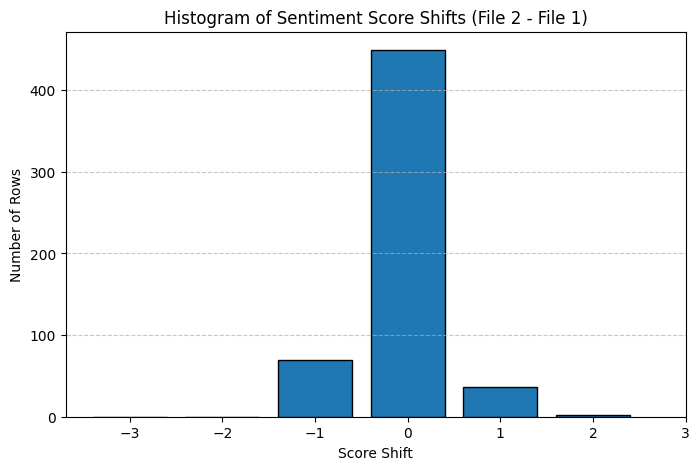

In [ ]:
#histogram 1
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV files
df1 = pd.read_csv('/content/output_11Apr_1.csv')
df2 = pd.read_csv('/content/output_11Apr_2.csv')

# Compute score differences
score_diff = df2['sentiment_deepseek'] - df1['sentiment_deepseek']

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(score_diff, bins=[-3, -2, -1, 0, 1, 2, 3], edgecolor='black', align='left', rwidth=0.8)
plt.title("Histogram of Sentiment Score Shifts (File 2 - File 1)")
plt.xlabel("Score Shift")
plt.ylabel("Number of Rows")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(-3, 4))
plt.show()


Here’s the analysis comparing the `sentiment_deepseek` scores between the two files:

- 📊 **Total Rows Compared**: 558
- 🔁 **Total Differences**: 98 rows
  - 🔼 **Scores Increased** (File 2 > File 1): 36 rows
  - 🔽 **Scores Decreased** (File 2 < File 1): 62 rows
  - ⚖️ **Scores Unchanged**: 460 rows

So overall, the second file tends to assign **lower sentiment scores** slightly more often than higher ones.

Would you like a breakdown of specific rows where the largest changes occurred, or a histogram of how the scores shifted?

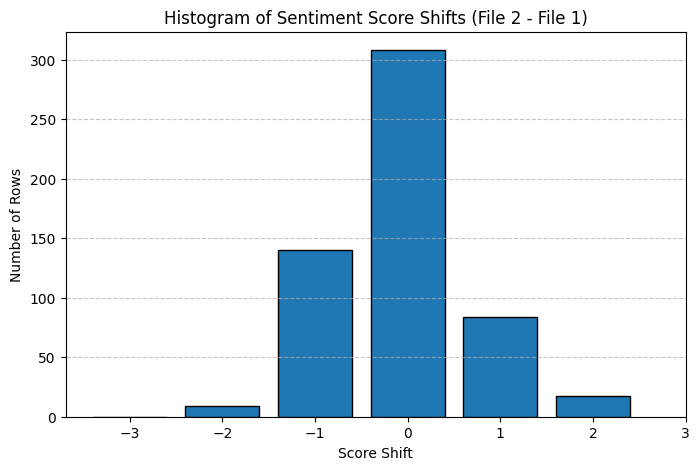

In [ ]:
#histogram 2
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV files
df1 = pd.read_csv('/content/output_11Apr_1.csv')
df2 = pd.read_csv('/content/sentiment_chainofthought.csv')

# Compute score differences
score_diff = df2['sentiment'] - df1['sentiment_deepseek']

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(score_diff, bins=[-3, -2, -1, 0, 1, 2, 3], edgecolor='black', align='left', rwidth=0.8)
plt.title("Histogram of Sentiment Score Shifts (File 2 - File 1)")
plt.xlabel("Score Shift")
plt.ylabel("Number of Rows")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(-3, 4))
plt.show()
